# CT-JEPA Data Preprocessing

This notebook prepares the LIDC-IDRI dataset for:

• Self-Supervised JEPA pretraining  
• Lung cancer classification  

Pipeline:
1. Load raw DICOM series
2. Resample to isotropic 1mm spacing
3. Lung window clipping [-1000, 400]
4. Normalize to [0,1]
5. Extract random 3D patches (96×96×96)
6. Save compressed patches (.npz)
7. Save preprocessing metadata

In [1]:
import sys
from pathlib import Path

# Set project root
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: /home/sreethanu/lidc_ldri_dataset_1/lung_cancer_vl_jepa_lidc


In [3]:
import os
import shutil
import gc
import numpy as np
import pandas as pd
from tqdm import tqdm

from src.utils.config import load_config
from src.utils.seed import set_global_seed
from src.preprocessing.preprocess import CTPreprocessor

# Load config
config = load_config(PROJECT_ROOT / "configs/jepa_config.yaml")

# Set seed
set_global_seed(config["project"]["seed"], deterministic=True)

print("Config loaded successfully.")

Setting global seed: 42
Enabling deterministic mode (may reduce performance)
Reproducibility configured successfully.
Config loaded successfully.


In [4]:
RAW_DICOM_DIR = PROJECT_ROOT / config["data"]["raw_dir"]
OUTPUT_DIR = PROJECT_ROOT / config["data"]["processed_dir"]

print("Raw DICOM dir:", RAW_DICOM_DIR)
print("Output dir:", OUTPUT_DIR)


Raw DICOM dir: /home/sreethanu/lidc_ldri_dataset_1/lung_cancer_vl_jepa_lidc/data/raw/LIDC-IDRI/LIDC_DATA
Output dir: /home/sreethanu/lidc_ldri_dataset_1/lung_cancer_vl_jepa_lidc/data/processed


In [5]:
patient_dirs = [
    folder for folder in RAW_DICOM_DIR.iterdir()
    if folder.is_dir() and len(list(folder.glob("*.dcm"))) > 50
]

patient_dirs = sorted(patient_dirs)

print("Total CT volumes found:", len(patient_dirs))

if config["project"].get("debug", False):
    print("DEBUG MODE ENABLED — Using first 10 patients only.")
    patient_dirs = patient_dirs[:10]


Total CT volumes found: 1018


In [6]:
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
    print("Deleted old processed directory.")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


Deleted old processed directory.


In [7]:
preprocessor = CTPreprocessor(
    clip_min=config["data"]["clip_min"],
    clip_max=config["data"]["clip_max"],
    target_spacing=tuple(config["data"]["spacing"]),
    patch_size=tuple(config["data"]["input_shape"][1:]),
    num_patches=3   # number of random patches per patient
)

print("CTPreprocessor initialized.")

CTPreprocessor initialized.


In [8]:
metadata_list = []

for patient_dir in tqdm(patient_dirs, desc="Processing Patients"):
    try:
        meta = preprocessor.preprocess_patient(
            str(patient_dir),
            str(OUTPUT_DIR),
            patient_dir.name
        )
        metadata_list.append(meta)

    except Exception as e:
        print(f"Error processing {patient_dir.name}: {e}")
        continue

print(f"\nProcessed {len(metadata_list)} patients successfully.")


Processing Patients:   1%|▏                   | 12/1018 [00:22<31:43,  1.89s/it]WARNING: In /tmp/SimpleITK-build/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x5625c7f61510): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.741489

Processing Patients:   3%|▋                   | 32/1018 [01:00<29:51,  1.82s/it]WARNING: In /tmp/SimpleITK-build/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x5625c7f61510): Non uniform sampling or missing slices detected,  maximum nonuniformity:3.77717

Processing Patients:  19%|███▌               | 191/1018 [06:44<31:47,  2.31s/it]WARNING: In /tmp/SimpleITK-build/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x5625c7f61510): Non uniform sampling or missing slices detected,  maximum nonuniformity:1.24532

Processing Patients:  40%|███████▌           | 408/1018 [14:49<33:15,  3.27s/it]WARNING: In /tmp/SimpleITK-build/ITK-prefix


Processed 1018 patients successfully.


In [9]:
metadata_df = pd.DataFrame(metadata_list)

metadata_path = OUTPUT_DIR / "metadata"
metadata_path.mkdir(parents=True, exist_ok=True)

metadata_df.to_csv(metadata_path / "preprocessing_metadata.csv", index=False)

print("Metadata saved to:", metadata_path / "preprocessing_metadata.csv")


Metadata saved to: /home/sreethanu/lidc_ldri_dataset_1/lung_cancer_vl_jepa_lidc/data/processed/metadata/preprocessing_metadata.csv


In [10]:
patch_root = OUTPUT_DIR / "patches"

bad_files = []
good_files = 0

for series in patch_root.iterdir():
    for patch_file in series.glob("*.npz"):
        data = np.load(patch_file)
        if "patch" in data.files and len(data.files) == 1:
            good_files += 1
        else:
            bad_files.append(patch_file)

print("Good patch files:", good_files)
print("Bad files:", len(bad_files))
print("Example bad files:", bad_files[:5])


Good patch files: 3054
Bad files: 0
Example bad files: []


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


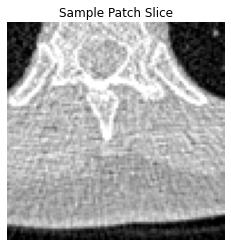

In [11]:
import matplotlib.pyplot as plt

sample_series = list(patch_root.iterdir())[0]
sample_patch = list(sample_series.glob("*.npz"))[0]

data = np.load(sample_patch)
volume = data["patch"]

slice_idx = volume.shape[0] // 2

plt.imshow(volume[slice_idx], cmap="gray")
plt.title("Sample Patch Slice")
plt.axis("off")
plt.show()


In [1]:
import os
print("Current working directory:")
print(os.getcwd())

Current working directory:
/home/sreethanu/lidc_ldri_dataset_1/lung_cancer_vl_jepa_lidc/notebooks


In [2]:
import os
print(os.listdir())

['._02_data_preprocessing.ipynb', '03_model_training.ipynb', '._03_model_training.ipynb', '04_model_evaluation.ipynb', '._01_data_exploration.ipynb', '01_data_exploration.ipynb', '._04_model_evaluation.ipynb', '03_pretrain_jepa.ipynb', '02_data_preprocessing.ipynb', '.ipynb_checkpoints', 'checkpoints']


# Import modules and Load Configuration

In [3]:
import os
import sys
import gc
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import random


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)


Project Root: /home/sreethanu/lidc_ldri_dataset_1/lung_cancer_vl_jepa_lidc


In [5]:
from src.utils.config import load_config
from src.utils.seed import set_global_seed
from src.preprocessing.preprocess import CTPreprocessor

# Load config and set seed

In [6]:
CONFIG_PATH = PROJECT_ROOT / "configs" / "jepa_config.yaml"
config = load_config(CONFIG_PATH)

set_global_seed(
    seed=config["project"]["seed"],
    deterministic=config["project"]["deterministic"]
)

print("Configuration loaded successfully.")


Setting global seed: 42
Enabling deterministic mode (may reduce performance)
Reproducibility configured successfully.
Configuration loaded successfully.


In [7]:
RAW_DICOM_DIR = PROJECT_ROOT / config["data"]["raw_dir"]
PROCESSED_DIR = PROJECT_ROOT / config["data"]["processed_dir"]

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Raw DICOM Dir:", RAW_DICOM_DIR)
print("Processed Dir:", PROCESSED_DIR)


Raw DICOM Dir: /home/sreethanu/lidc_ldri_dataset_1/lung_cancer_vl_jepa_lidc/data/raw/LIDC-IDRI/LIDC_DATA
Processed Dir: /home/sreethanu/lidc_ldri_dataset_1/lung_cancer_vl_jepa_lidc/data/processed


In [9]:
# Initialize preprocessor
preprocessor = CTPreprocessor(
    clip_min=config["data"]["clip_min"],
    clip_max=config["data"]["clip_max"],
    target_spacing=tuple(config["data"]["spacing"]),
    patch_size=tuple(config["data"]["input_shape"][1:]),
    num_patches=3  # number of random raw patches per patient
)

print("CTPreprocessor initialized.")



CTPreprocessor initialized.


# Identify Valid Patients

In [13]:
patient_dirs = [
    folder for folder in RAW_DICOM_DIR.iterdir()
    if folder.is_dir() and len(list(folder.glob("*.dcm"))) > 50
]

patient_dirs = sorted(patient_dirs)

print("Total CT volumes found:", len(patient_dirs))


Total CT volumes found: 1018


In [ ]:
if config["project"]["debug"]:
    print("DEBUG MODE ENABLED — Using first 10 patients only.")
    patient_dirs = patient_dirs[:10]

In [ ]:
patch_root = PROJECT_ROOT / "data/processed/patches"

print("Patch folder exists:", patch_root.exists())

print("Example patient folders:")
print([p.name for p in list(patch_root.iterdir())[:5]])


In [ ]:
import numpy as np

sample_patient = list(patch_root.iterdir())[0]
sample_patch = list(sample_patient.glob("*.npz"))[0]

data = np.load(sample_patch)

print("Patch shape:", data["context"].shape)

In [10]:
import pydicom
from pathlib import Path

patch_root = PROJECT_ROOT / "data/processed/patches"

sample_folder = list(patch_root.iterdir())[0]

sample_dicom_folder = PROJECT_ROOT / config["data"]["raw_dir"] / sample_folder.name

# find one DICOM file
dcm_file = list(sample_dicom_folder.glob("*.dcm"))[0]

ds = pydicom.dcmread(dcm_file)

print("Series UID Folder Name:", sample_folder.name)
print("DICOM PatientID:", ds.PatientID)


FileNotFoundError: [Errno 2] No such file or directory: '/home/sreethanu/lidc_ldri_dataset_1/lung_cancer_vl_jepa_lidc/data/processed/patches'

In [14]:
from pathlib import Path

print("Current working directory:", Path.cwd())


Current working directory: /home/sreethanu/lidc_ldri_dataset_1/lung_cancer_vl_jepa_lidc/notebooks


In [15]:
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
patch_root = PROJECT_ROOT / "data/processed/patches"

print("Project root:", PROJECT_ROOT)
print("Patch folder exists:", patch_root.exists())
print("Patch folder path:", patch_root)


Project root: /home/sreethanu/lidc_ldri_dataset_1/lung_cancer_vl_jepa_lidc
Patch folder exists: False
Patch folder path: /home/sreethanu/lidc_ldri_dataset_1/lung_cancer_vl_jepa_lidc/data/processed/patches


In [12]:
metadata_list = []

for patient_dir in tqdm(patient_dirs, desc="Processing Patients"):
    try:
        meta = preprocessor.preprocess_patient(
            str(patient_dir),
            str(OUTPUT_DIR),
            patient_dir.name
        )
        metadata_list.append(meta)

    except Exception as e:
        print(f"Error processing {patient_dir.name}: {e}")
        continue

print(f"\nProcessed {len(metadata_list)} patients successfully.")

Processing Patients: 100%|██████████████| 1018/1018 [00:00<00:00, 113284.38it/s]

Error processing 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860: name 'OUTPUT_DIR' is not defined
Error processing 1.3.6.1.4.1.14519.5.2.1.6279.6001.100332161840553388986847034053: name 'OUTPUT_DIR' is not defined
Error processing 1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793540579077826395208: name 'OUTPUT_DIR' is not defined
Error processing 1.3.6.1.4.1.14519.5.2.1.6279.6001.100530488926682752765845212286: name 'OUTPUT_DIR' is not defined
Error processing 1.3.6.1.4.1.14519.5.2.1.6279.6001.100620385482151095585000946543: name 'OUTPUT_DIR' is not defined
Error processing 1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016233746780170740405: name 'OUTPUT_DIR' is not defined
Error processing 1.3.6.1.4.1.14519.5.2.1.6279.6001.100684836163890911914061745866: name 'OUTPUT_DIR' is not defined
Error processing 1.3.6.1.4.1.14519.5.2.1.6279.6001.100953483028192176989979435275: name 'OUTPUT_DIR' is not defined
Error processing 1.3.6.1.4.1.14519.5.2.1.6279.6001.101228986346984399347

# PatientID Mapping
## Build Mapping Table

In [ ]:
import pydicom

series_to_patient = {}

raw_root = PROJECT_ROOT / config["data"]["raw_dir"]

for series_folder in tqdm(raw_root.iterdir(), desc="Building UID Mapping"):

    if not series_folder.is_dir():
        continue

    dcm_files = list(series_folder.glob("*.dcm"))

    if len(dcm_files) == 0:
        continue

    ds = pydicom.dcmread(dcm_files[0], stop_before_pixels=True)

    series_uid = series_folder.name
    patient_id = ds.PatientID  # e.g., LIDC-IDRI-0744

    series_to_patient[series_uid] = patient_id

print("Total mapped series:", len(series_to_patient))


## XML Parsing Section

In [ ]:
XML_ROOT = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "metadata"
    / "LIDC-XML-only"
    / "tcia-lidc-xml"
)

print("XML Root Path:", XML_ROOT)
print("Exists:", XML_ROOT.exists())

In [ ]:
xml_files = list(XML_ROOT.rglob("*.xml"))

print("Total XML Files Found:", len(xml_files))
print("Example XML:", xml_files[:3])



In [ ]:
def extract_patient_malignancy(xml_file):

    tree = ET.parse(xml_file)
    root = tree.getroot()

    malignancy_scores = []

    for elem in root.iter():
        if elem.tag.endswith("malignancy"):
            try:
                malignancy_scores.append(int(elem.text))
            except:
                continue

    if len(malignancy_scores) == 0:
        return None

    return np.mean(malignancy_scores)


In [ ]:
patient_labels = []

for folder in tqdm(XML_ROOT.iterdir(), desc="Parsing XML"):

    if not folder.is_dir():
        continue

    for xml_file in folder.glob("*.xml"):

        numeric_id = xml_file.stem  # e.g., 744

        # Convert to full PatientID format
        full_patient_id = f"LIDC-IDRI-{int(numeric_id):04d}"

        malignancy_score = extract_patient_malignancy(xml_file)

        if malignancy_score is None:
            continue

        binary_label = 1 if malignancy_score >= 3 else 0

        patient_labels.append({
            "patient_id": full_patient_id,
            "malignancy_score": malignancy_score,
            "label": binary_label
        })

labels_df = pd.DataFrame(patient_labels)

print("XML Patients Parsed:", len(labels_df))


In [ ]:
print(labels_df.head())

In [ ]:
final_labels = []

for series_uid, patient_id in series_to_patient.items():

    match = labels_df[labels_df["patient_id"] == patient_id]

    if len(match) == 0:
        continue

    label = int(match["label"].values[0])

    final_labels.append({
        "series_uid": series_uid,
        "patient_id": patient_id,
        "label": label
    })

final_labels_df = pd.DataFrame(final_labels)

print("Matched Series:", len(final_labels_df))


In [ ]:
print("Patch folders:", len(series_to_patient))


In [ ]:
patch_series = set(series_to_patient.keys())
label_series = set(final_labels_df["series_uid"])

print("Intersection:", len(patch_series & label_series))


## Create Final labels.csv

In [ ]:
final_labels = []

for series_uid, patient_id in series_to_patient.items():

    match = labels_df[labels_df["patient_id"] == patient_id]

    if len(match) == 0:
        continue

    label = int(match["label"].values[0])

    final_labels.append({
        "series_uid": series_uid,
        "patient_id": patient_id,
        "label": label
    })

final_labels_df = pd.DataFrame(final_labels)

print("Final matched series:", len(final_labels_df))


In [ ]:
metadata_dir = PROCESSED_DIR / "metadata"
metadata_dir.mkdir(parents=True, exist_ok=True)

final_labels_df.to_csv(metadata_dir / "labels.csv", index=False)

print("Final labels.csv saved successfully.")


In [ ]:

patch_root = PROJECT_ROOT / "data/processed/patches"

# Pick random series
series_list = list(patch_root.iterdir())
random_series = random.choice(series_list)

# Pick random patch
patch_files = list(random_series.glob("*.npz"))
random_patch = random.choice(patch_files)

print("Series UID:", random_series.name)
print("Patch File:", random_patch.name)

data = np.load(random_patch)
volume = data["context"]  # shape (96, 96, 96)

print("Volume shape:", volume.shape)
print("Min:", volume.min(), "Max:", volume.max())


In [ ]:
# Take center slices
z_mid = volume.shape[0] // 2
y_mid = volume.shape[1] // 2
x_mid = volume.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(volume[z_mid, :, :], cmap="gray")
axes[0].set_title("Axial (Z mid)")

axes[1].imshow(volume[:, y_mid, :], cmap="gray")
axes[1].set_title("Coronal (Y mid)")

axes[2].imshow(volume[:, :, x_mid], cmap="gray")
axes[2].set_title("Sagittal (X mid)")

for ax in axes:
    ax.axis("off")

plt.show()


In [ ]:
plt.hist(volume.flatten(), bins=100)
plt.title("Intensity Distribution (Normalized)")
plt.show()
